In [74]:
import os
import wget
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec


### PART 2.1. Download and convert image

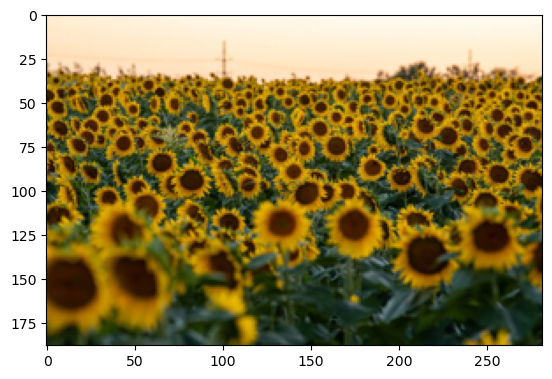

In [75]:
'''
Download and resize an image from URL
'''
def get_image(url, filename, ratio):
    jpg = f'{filename}.jpg'
    png = f'{filename}.png'
    if not os.path.exists(jpg):
        wget.download(url, jpg)

    img = Image.open(jpg)
    new_size = (int(img.width * ratio), int(img.height * ratio))
    img_resized = img.resize(new_size)
    img_resized.save(png, format="PNG")
    return plt.imread(png)

url = 'https://showme.missouri.edu/wp-content/uploads/2022/09/092722Sunflowers5-940x627.jpg'
img = get_image(url, 'sunflower', 0.3)
plt.imshow(img)

### PART 2.2. Define LoG function and show results

In [76]:
"""
Define LoG filter function
should return np.array 
"""
def LoG(sigma=1, size=19) -> np.array:
    # Ensure size is odd for proper centering
    if size % 2 == 0:
        size += 1
        
    log_filter = np.zeros((size, size))
    center = size // 2
    
    for x in range(size):
        for y in range(size):
            # Calculate centered coordinates
            X = x - center
            Y = y - center
            # Normalized squared distance
            r_squared = (X**2 + Y**2)
            # Apply LoG formula
            log_filter[x, y] = -1.0 / (np.pi * sigma**4) * (1 - r_squared/(2*sigma**2)) * np.exp(-r_squared/(2*sigma**2))
            
    return log_filter

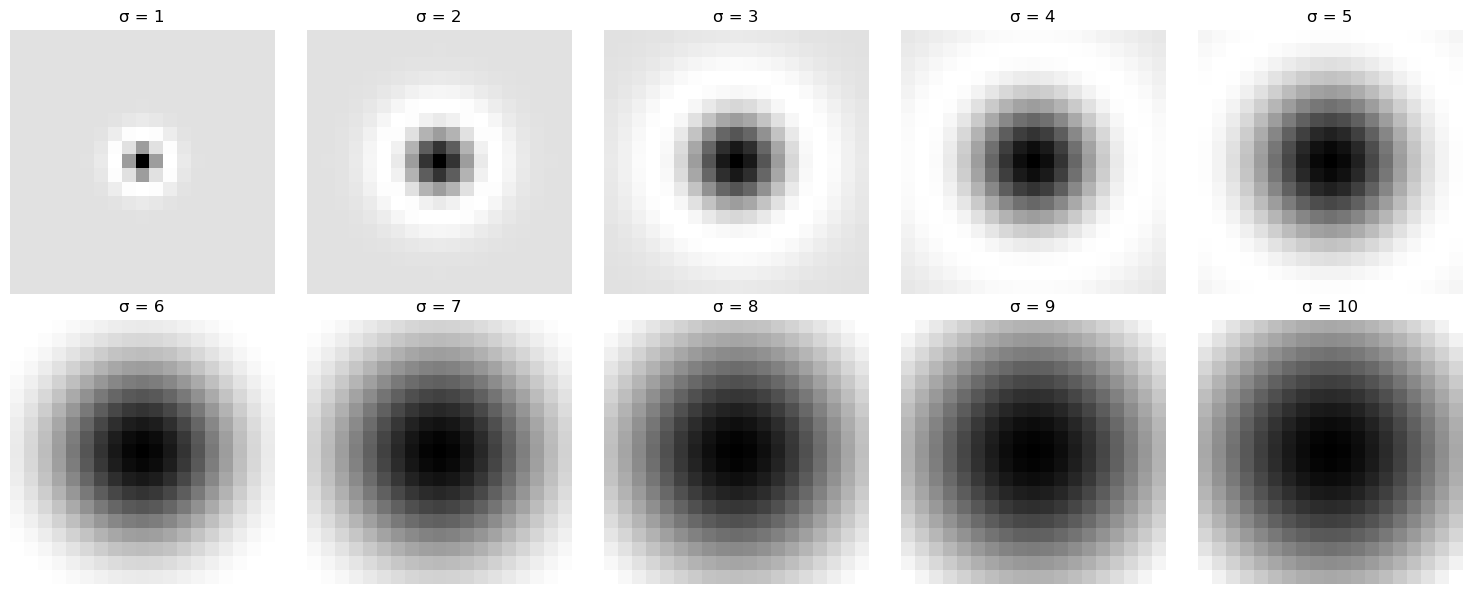

In [77]:
'''
Visualize LoG filters for sigmas 1-10
'''
figure = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(2, 5, figure)

for i in range(1, 11):
    sigma = i
    log = LoG(sigma=sigma)
    ax = figure.add_subplot(gs[(i-1)//5, (i-1)%5])
    ax.imshow(log, cmap='gray')
    ax.set_title(f'σ = {sigma}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### PART 2.3. Define filterImg and trackScale

In [78]:
'''
Performs convolution of image with filter
'''
def filterImg(img, fil):
    # Get image and filter dimensions
    img_height, img_width = img.shape
    k_height, k_width = fil.shape
    
    # Calculate padding
    pad_h = k_height // 2
    pad_w = k_width // 2
    
    # Pad the image
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    # Create output array
    output = np.zeros_like(img, dtype=np.float64)
    
    # Perform convolution
    for i in range(img_height):
        for j in range(img_width):
            output[i, j] = np.sum(padded[i:i+k_height, j:j+k_width] * fil)
                
    return output

In [79]:
'''
Visualize the Result Images
'''
def plot_images(imgs, columns=3, title=""):
    rows = (len(imgs) // columns) + (1 if len(imgs) % columns > 0 else 0)
    figure = plt.figure(figsize=(columns * 4, rows * 4))
    gs = gridspec.GridSpec(rows, columns, figure)

    for i, img in enumerate(imgs):
        if i < len(imgs):
            ax = figure.add_subplot(gs[i//columns, i%columns])
            ax.imshow(img, cmap='gray')
            ax.axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [80]:
'''
Track scales for blob detection across multiple scales
from the requirements 
'''
def trackScale(img, sigmas, size, threshold):
    # Create array to store filter responses
    imgs = []
    
    # 1) Apply LoG filter at each scale and normalize by scale
    for s in sigmas:
        # 2) Multiply by s^2 for scale normalization
        resp = (s**2) * filterImg(img, LoG(s, size))
        imgs.append(resp)
    
    # Convert to numpy array
    imgs = np.array(imgs)
    
    # Visualize filter responses
    plot_images(imgs, columns=min(6, len(sigmas)), title="LoG Responses at Different Scales")

    # 3) Find maximum value for each pixel and corresponding sigma index
    filMaxScale = np.max(imgs, axis=0) # <--- saved as filMaxScale
    scale_index = np.argmax(imgs, axis=0)

    # 4) Visualize results
    figure = plt.figure(figsize=(10, 10))
    ax = figure.add_subplot(111)
    ax.imshow(img, cmap='gray')
    ax.set_title("LoG Scale Blob Detection")
    
    # Find coordinates where response is above threshold
    coords = np.argwhere(filMaxScale >= threshold)
    
    # Draw circles at detected blobs
    for (y, x) in coords:
        sigma_candidate = sigmas[scale_index[y, x]]
        # Convert sigma to radius (sqrt(3)*sigma is a common conversion)
        radius = np.sqrt(3) * sigma_candidate
        circle = plt.Circle((x, y), radius, color='red', fill=False, linewidth=1.5)
        ax.add_patch(circle)

    ax.axis('off')
    plt.show()
    
    return filMaxScale

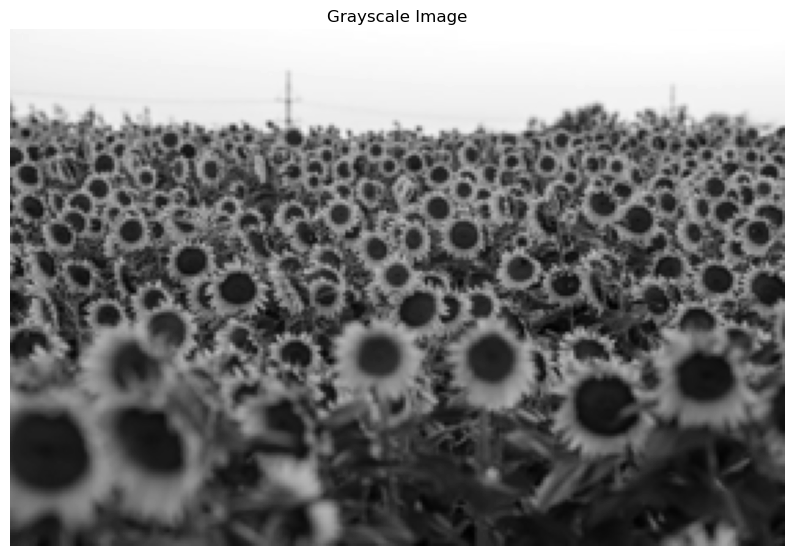

In [81]:
# Convert to grayscale (ITU-R BT.601 standard)
grayscale_img = img @ [0.2989, 0.5870, 0.1140]
plt.figure(figsize=(10, 8))
plt.imshow(grayscale_img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

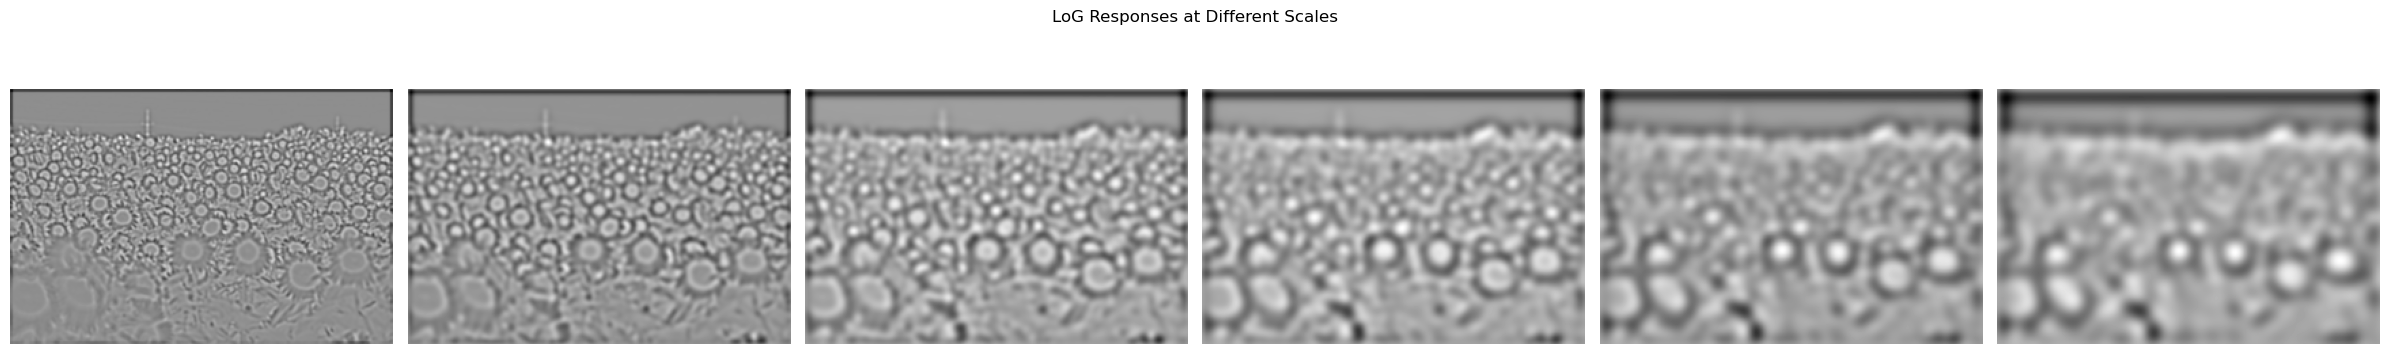

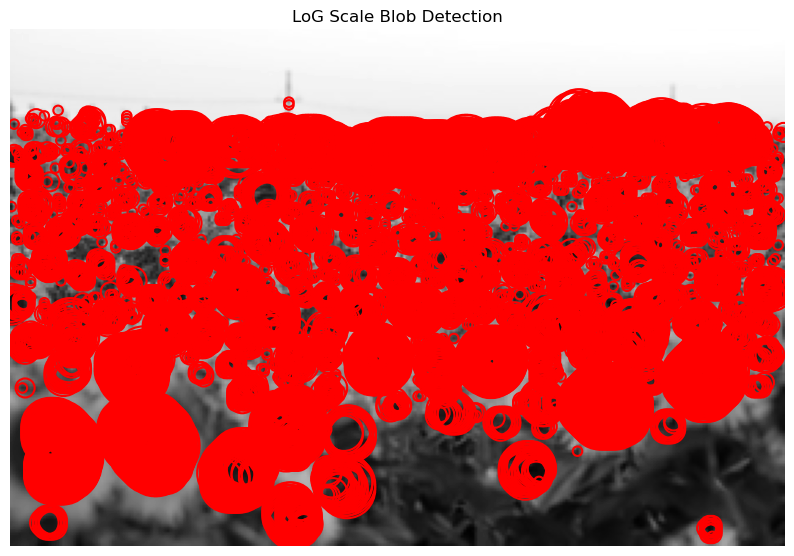

In [ ]:
'''
Run blob detection
We started with threshold=0.100
which was... too much blob
'''
sigmas = np.arange(1, 7)  # Sigma range [1, 2, 3, 4, 5, 6]
result = trackScale(grayscale_img, sigmas, size=61, threshold=0.100)

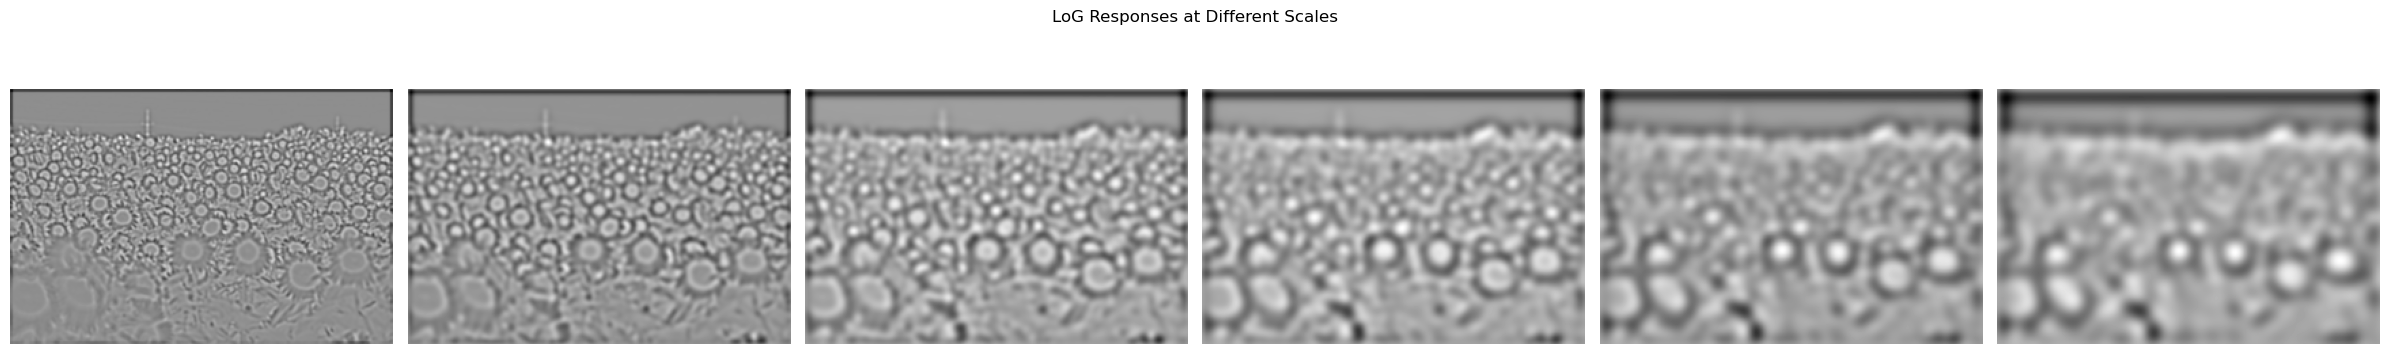

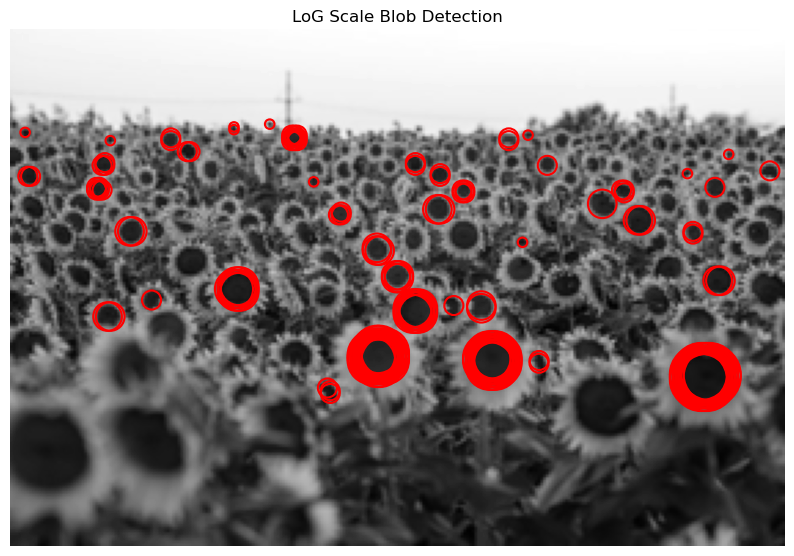

In [100]:
'''
Run blob detection
So, we tested (by increasing 0.01 from 0.1) and We think that 0.213344 seems the best.
We could go further to decimal...but we thought 6 digits are enough

'''
sigmas = np.arange(1, 7)  # Sigma range [1, 2, 3, 4, 5, 6]
result = trackScale(grayscale_img, sigmas, size=61, threshold=0.213344)

### Observation Report


- Initial Setting: We began with a low threshold value of 0.1 as a baseline. This initial value proved to be excessively permissive, resulting in the detection of numerous false positives, particularly dark spots that did not represent actual sunflower blobs.

- Iterative Testing: We methodically increased the threshold in increments of 0.01, evaluating detection accuracy at each step. This progressive adjustment allowed us to observe the trade-off between sensitivity and specificity in blob detection.

- Optimal Value: Through this iterative process, we identified '0.213344' as the critical threshold value. At this level, we achieved an optimal balance where:

- Validation: When exceeding the threshold of 0.214, we observed that the detector began to incorrectly identify regions in the upper right portion of the image (likely some background elements) as blobs, despite these not conforming to the characteristic circular pattern of sunflowers.(Just in case, We also run 0.213343 to show the some background element)

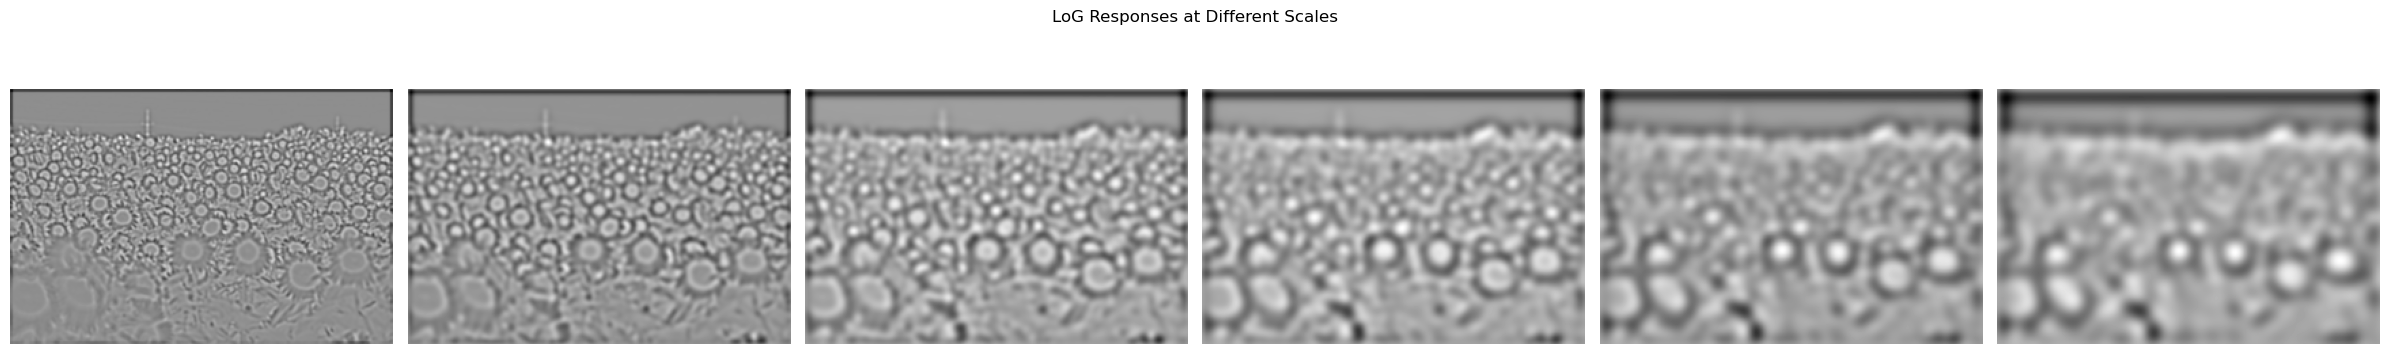

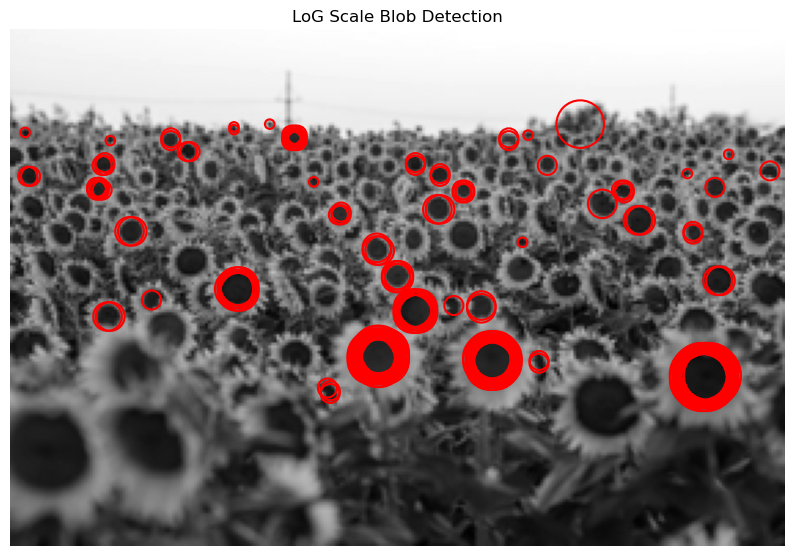

In [102]:
'''
Run blob detection
So, we tested (by increasing 0.01 from 0.1) and We think that 0.213344 seems the best.
We could go further to decimal...but we thought 6 digits are enough

'''
sigmas = np.arange(1, 7)  # Sigma range [1, 2, 3, 4, 5, 6]
result = trackScale(grayscale_img, sigmas, size=61, threshold=0.213343)